In [16]:
import os
import cv2
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from torchvision import io
from skimage.metrics import structural_similarity as ssim

In [52]:
original_images_folder_path = '/home/miguel/GI/0 - Data Exploration & Analysis/UW-Madison/stomach_data_and_masks_preparation/stomach_data_and_masks'

filename_images = {}
original_sample_filenames = os.listdir(original_images_folder_path)

for filename in tqdm(original_sample_filenames):
    if filename.endswith('.png') and 'stomach_mask' not in filename:
        img_path = os.path.join(original_images_folder_path, filename)
        image = io.read_image(img_path)
        filename_images[filename] = image
    else:
        continue

  0%|          | 0/17254 [00:00<?, ?it/s]

100%|██████████| 17254/17254 [00:08<00:00, 2052.79it/s]


In [7]:
sample_size_name = 'all'

In [53]:
original_image = filename_images[filename]

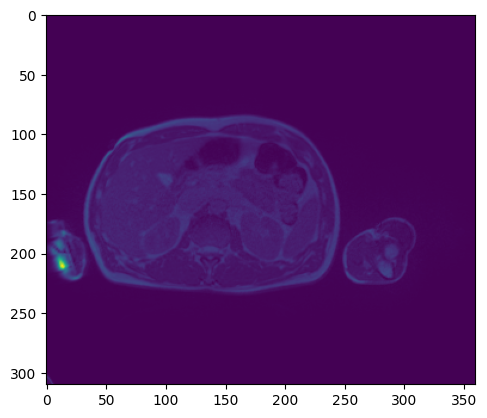

In [58]:
plt.imshow(original_image[0])

/tmp/ipykernel_3554614/3246010527.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  original_image = (original_image / np.array(original_image.flatten()).max()) * 255


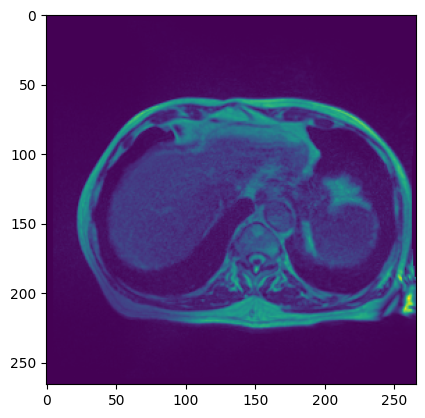

In [101]:
plt.imshow(original_image)

In [123]:
base = f'/home/miguel/GI/1.5 - Synthetic Data Generation/diffuse-gen/diffuse-gen/image_samples_{sample_size_name}'

latest_dir = max(
    (entry for entry in os.scandir(base) if entry.is_dir()),
    key=lambda e: e.stat().st_mtime      # use st_ctime on macOS / Windows if you want “created” time
).path

img_path = max(
    (entry for entry in os.scandir(latest_dir) if entry.is_file() and entry.name.endswith('.pkl') and 'styled' not in entry.name),
    key=lambda e: e.stat().st_mtime
).path

styled_img_path = '/'.join(img_path.split('/')[:-1] + [img_path.split('/')[-1].replace('samples_', 'styled_samples_')])
with open(img_path, "rb") as f:
    images = pickle.load(f)
with open(styled_img_path, "rb") as f:
    styled_images = pickle.load(f)

total_ssim = 0

for key in list(styled_images.keys())[:10]:
    styled_image = styled_images[key]
    styled_image = styled_image[0]

    # Split image and mask
    image = styled_image[:, :, :3]  # RGB image (values 0-255)
    mask = styled_image[:, :, 3]    # Single-channel mask (values 0-255)

    # Evaluate SSIM compared to its original base image
    filename = key.split('/')[-1]

    original_image = filename_images[filename][0]
    original_image = (original_image / np.array(original_image.flatten()).max()) * 255
    original_image = np.asarray(original_image).astype(np.uint8)
    original_image = cv2.resize(original_image, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_CUBIC)

    # Convert images to grayscale
    image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Calculate SSIM
    image_gray = image_gray.astype(np.uint8)
    original_image_gray = original_image_gray.astype(np.uint8)

    ssim_value = ssim(image_gray, original_image_gray)
    mse_value = np.mean((image_gray - original_image_gray) ** 2)

    total_ssim = total_ssim + ssim_value

mean_ssim = total_ssim / len(styled_images)

/tmp/ipykernel_3554614/4202430185.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  original_image = (original_image / np.array(original_image.flatten()).max()) * 255


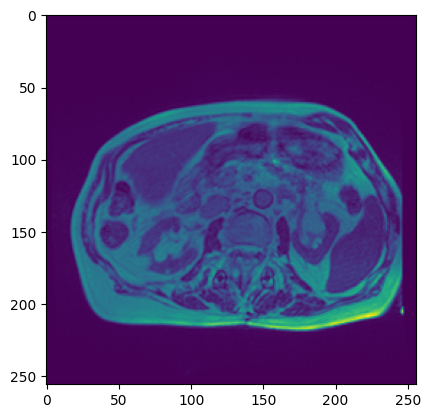

In [127]:
plt.imshow(original_image)

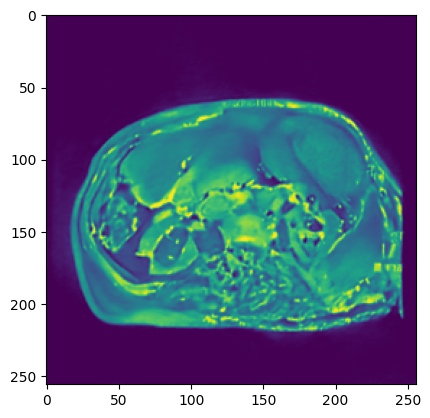

In [128]:
plt.imshow(image_gray)

/tmp/ipykernel_3554614/1181459194.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  original_image = np.array(original_image)


In [44]:
mean_ssim

np.float64(0.16836206630430228)

In [162]:
sample_size_names = [
    {'sample_size': None, 'path': '/home/miguel/GI/1.5 - Synthetic Data Generation/diffuse-gen/diffuse-gen/checkpoints/diffgen-2025-06-11-23-11/progress.csv'},
    {'sample_size': 110, 'path': '/home/miguel/GI/1 - Segmentation/Synthesis-performance-n-samples/checkpoints-110/diffgen-2025-06-18-01-07/progress.csv'},
    {'sample_size': 300, 'path': '/home/miguel/GI/1 - Segmentation/Synthesis-performance-n-samples/checkpoints-300/diffgen-2025-06-18-05-00/progress.csv'},
    {'sample_size': 200, 'path': '/home/miguel/GI/1 - Segmentation/Synthesis-performance-n-samples/checkpoints-200/diffgen-2025-06-18-08-53/progress.csv'}
]

In [163]:
progress

,grad_norm,loss,loss_q3,mse,mse_q3,param_norm,samples,step,vb,vb_q3,loss_q0,loss_q1,loss_q2,mse_q0,mse_q1,mse_q2,vb_q0,vb_q1,vb_q2
0,3.940486,1.009274,1.009274,0.997958,0.997958,346.934985,1,0,0.011316,0.011316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.457236,0.854991,0.897330,0.845329,0.885890,346.936605,11,10,0.009661,0.011440,0.829225,0.810001,0.888931,0.813281,0.803993,0.880990,0.015944,0.006008,0.007941
2,2.874004,0.542433,0.554272,0.536812,0.547018,346.948175,21,20,0.005621,0.007254,0.541776,0.624028,0.416105,0.537100,0.619576,0.412072,0.004676,0.004452,0.004033
3,2.507587,0.364886,0.279066,0.358811,0.275633,346.968830,31,30,0.006075,0.003433,0.803732,0.352677,0.372222,0.772788,0.350056,0.368526,0.030945,0.002621,0.003696
4,1.515348,0.163623,0.162596,0.162126,0.160348,346.995117,41,40,0.001497,0.002248,NaN,0.180656,0.155278,NaN,0.179352,0.153809,NaN,0.001305,0.001468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,0.082220,0.011349,0.000211,0.011252,0.000208,395.225446,49961,49960,0.000097,0.000003,0.017400,0.020482,0.000904,0.017240,0.020336,0.000894,0.000160,0.000147,0.000009
4997,0.082749,0.023222,0.000403,0.022816,0.000398,395.230581,49971,49970,0.000407,0.000005,0.085768,0.026666,0.001637,0.083963,0.026474,0.001622,0.001805,0.000192,0.000015
4998,0.081571,0.024407,0.000314,0.024108,0.000310,395.235113,49981,49980,0.000299,0.000004,0.066083,0.020912,0.002743,0.065201,0.020761,0.002720,0.000882,0.000150,0.000023
4999,0.050827,0.010084,0.000262,0.010005,0.000258,395.238375,49991,49990,0.000079,0.000003,0.048659,0.022597,0.002841,0.048261,0.022433,0.002816,0.000398,0.000164,0.000025


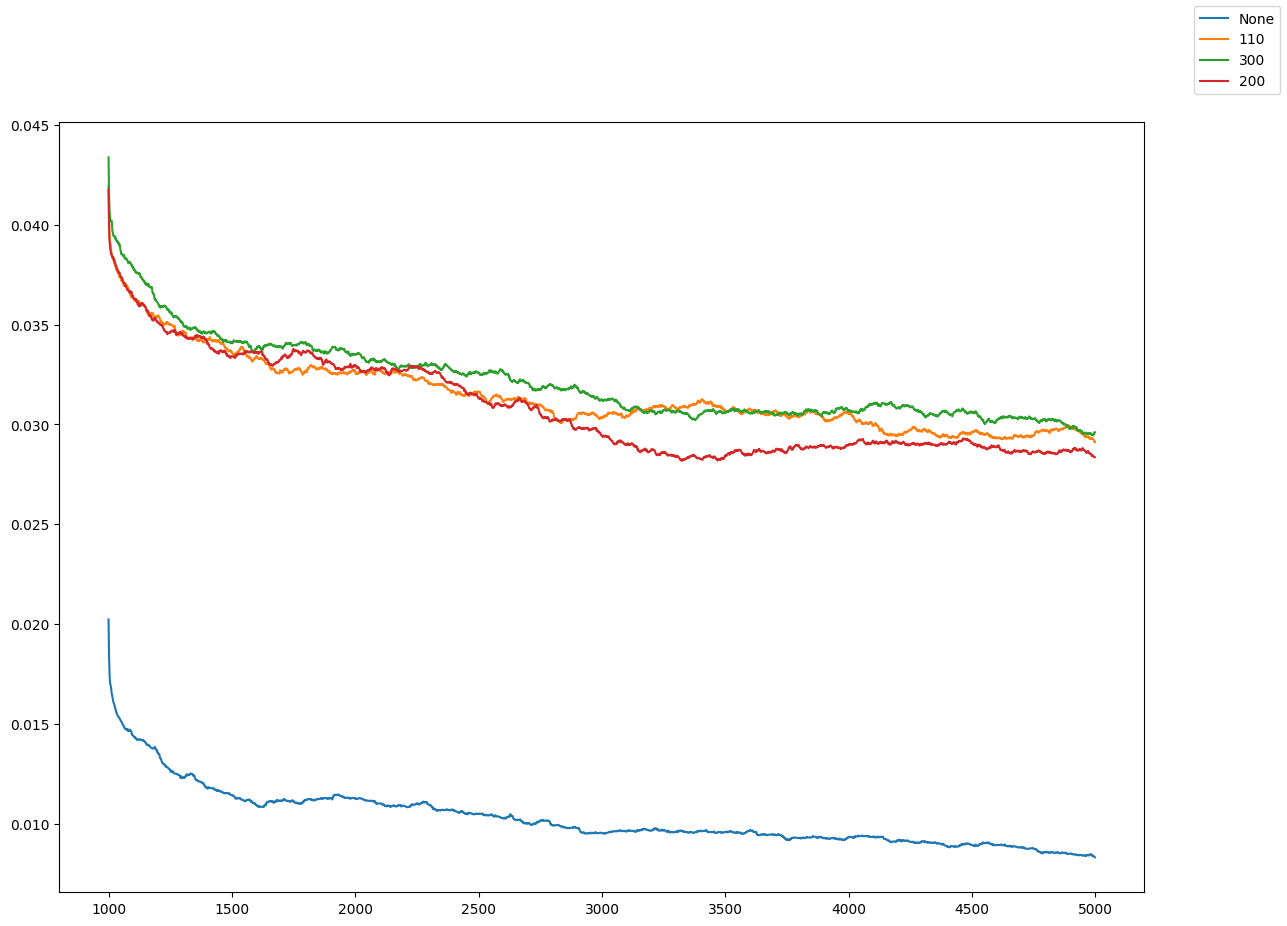

In [168]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
for sample_size_data in sample_size_names:
    progress = pd.read_csv(sample_size_data['path'])
    # ax.set_title(f"SSIM - {sample_size_data['sample_size']}")
    ax.plot(progress['mse'].rolling(1000).mean()[:5000], label=f"{sample_size_data['sample_size']}")

fig.legend()
fig.show()


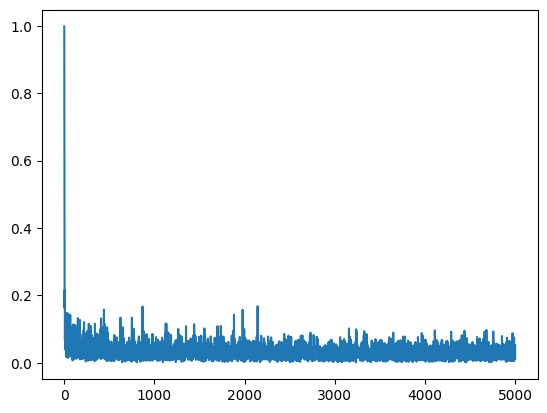

In [165]:
plt.plot(progress['mse'])

In [1]:
import os
import sys
import torch

In [2]:
sys.path.append(os.path.dirname(os.getcwd()))

from discriminator import CNNClassifier, train_discriminator

In [3]:
import cv2
from torchvision import transforms

def min_max_normalize(tensor, min_val=0.0, max_val=1.0):
    tensor_min = tensor.min()
    tensor_max = tensor.max()
    normalized_tensor = (tensor - tensor_min) / (tensor_max - tensor_min) * (max_val - min_val) + min_val
    return normalized_tensor

def resize_torch_tensor(tensor, w=256, h=256):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((w, h)),
    ])
    tensor = transform(tensor)
    tensor = tensor.float()

    tensor = min_max_normalize(tensor)

    return tensor

class RealAndSyntheticImageDataset(torch.utils.data.Dataset):
    def __init__(self, num_samples, synthetic_images_folder_path, real_images_folder_path):
        synthetic_images = os.listdir(synthetic_images_folder_path)

        real_images = os.listdir(real_images_folder_path)

        if len(synthetic_images) < num_samples:
            raise ValueError(f"Not enough synthetic images. Found {len(synthetic_images)}, but requested {num_samples}.")
        
        if len(real_images) < num_samples:
            raise ValueError(f"Not enough real images. Found {len(real_images)}, but requested {num_samples}.")
        
        synthetic_images_paths = [os.path.join(synthetic_images_folder_path, img) for img in synthetic_images[:(num_samples)]]
        real_images_paths = [os.path.join(real_images_folder_path, img) for img in real_images[:(num_samples)]]

        self.paths = []
        self.labels = []
        # Interleave the paths
        for i in range(min(len(synthetic_images_paths), len(real_images_paths))):
            self.paths.append(synthetic_images_paths[i])
            self.paths.append(real_images_paths[i])
            self.labels.append(1)
            self.labels.append(0)
    
        self.length = len(self.paths)
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        # Return a random 1×266×266 tensor and a random binary label
        image_path = self.paths[idx]
        image_data = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Resize and normalize the loaded data
        image_data = resize_torch_tensor(image_data)

        label = self.labels[idx]
        
        return image_data, label


In [4]:
synthetic_folder_path = 'similarity_diffusion/images/all/synthetic'
real_folder_path = 'similarity_diffusion/images/all/real'

In [5]:
synthetic_folder_path

'similarity_diffusion/images/all/synthetic'

In [6]:
discriminator_dataset = RealAndSyntheticImageDataset(
    100, synthetic_folder_path, real_folder_path
)

discriminator_model = CNNClassifier()


In [7]:
discriminator_training_results, discriminator_cv_val_results, discriminator_testing_results = train_discriminator(
    discriminator_model,
    discriminator_dataset,
    None,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=100,
    lr=0.001,
)

inputs torch.Size([1, 1, 256, 256])
tensor([0.4675], device='cuda:0', grad_fn=<SqueezeBackward1>) tensor([1.], device='cuda:0') train


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.